# 06 - Smoothing Parameter Effect on Classification

Fix **K=10** coefficients per arm, fix one smoothing method at a time, and sweep its
parameters across all three bases (Chebyshev, Legendre, B-spline).

For every (basis, smoothing_method, param_value) combination we:
1. Smooth spectra -> fit basis -> L2-normalise coefficients (in-memory, not saved).
2. Run logistic regression with full HPO (same pipeline as `05_logreg_smoothed.py`).
3. Aggregate metrics across 10 train/test splits.

Sections:
- **Baseline** -- no smoothing
- **Gaussian** -- sigma sweep
- **Savitzky-Golay** -- window_length sweep (polyorder=3 fixed)
- **Spline** -- s_factor sweep
- **Analysis** -- comparison plots and summary table

In [8]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path
import json
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
SCRIPT_PATH = ROOT / "02_generate_basis_features.py"
sys.modules.pop("bp_basis_step02", None)
spec = spec_from_file_location("bp_basis_step02", SCRIPT_PATH)
step02 = module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = step02
spec.loader.exec_module(step02)

from _common import (
    BP_SAMPLED_CSV,
    DATA_DIR,
    RESULTS_DIR,
    RP_SAMPLED_CSV,
    flatten_feature_blocks,
    l2_normalize,
)

In [9]:
K = 10
BASES = ["chebyshev", "legendre", "bspline"]
RANDOM_STATE = 42
N_ITER_HPO = 50

bp = step02.load_block(BP_SAMPLED_CSV)
rp = step02.load_block(RP_SAMPLED_CSV)
step02.check_alignment(bp, rp)

splits_path = DATA_DIR / "splits.json"
with splits_path.open() as fh:
    splits_dict = json.load(fh)
split_names = sorted(splits_dict.keys())

print(f"BP shape: {bp.flux.shape}")
print(f"RP shape: {rp.flux.shape}")
print(f"Splits:   {len(split_names)}")
print(f"K={K}, bases={BASES}")

BP shape: (2815, 154)
RP shape: (2815, 193)
Splits:   10
K=10, bases=['chebyshev', 'legendre', 'bspline']


---
## Classification helpers

Same pipeline as `05_logreg_smoothed.py`:
StandardScaler -> LogisticRegression (saga), RandomizedSearchCV (n_iter=50),
Youden threshold on OOF predictions.

In [10]:
def pick_youden_threshold(y_true, y_prob, grid_size=200):
    thresholds = np.linspace(0, 1, grid_size)
    best_j, best_thr = -1.0, 0.5
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0
        if j > best_j:
            best_j, best_thr = j, float(thr)
    return best_thr


def evaluate(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    acc = (tp + tn) / (tp + tn + fp + fn)
    f1 = (2 * prec * sens) / (prec + sens) if (prec + sens) else 0.0
    return {
        "threshold": threshold,
        "sensitivity": sens,
        "specificity": spec,
        "precision": prec,
        "accuracy": acc,
        "f1": f1,
        "youden_j": sens + spec - 1.0,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob),
    }


def process_cell(X_all, y_all, train_idx, test_idx, n_iter=N_ITER_HPO):
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    X_tr, y_tr = X_all[train_idx], y_all[train_idx]
    X_te, y_te = X_all[test_idx], y_all[test_idx]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    param_dist = {
        "clf__C": loguniform(1e-3, 1e3),
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["saga"],
        "clf__class_weight": [None, "balanced"],
    }
    search = RandomizedSearchCV(
        pipeline, param_dist, n_iter=n_iter, cv=inner_cv,
        scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1,
        error_score="raise",
    )
    search.fit(X_tr, y_tr)
    best_pipe = search.best_estimator_

    oof_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    y_prob_oof = cross_val_predict(
        best_pipe, X_tr, y_tr, cv=oof_cv, method="predict_proba", n_jobs=-1,
    )[:, 1]
    thr = pick_youden_threshold(y_tr, y_prob_oof)

    y_prob_te = best_pipe.predict_proba(X_te)[:, 1]
    metrics = evaluate(y_te, y_prob_te, thr)
    metrics["best_cv_roc_auc"] = search.best_score_
    best_params = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    return metrics, best_params

In [11]:
def generate_features(basis, smoothing, smooth_kwargs):
    """Smooth -> fit basis -> L2-normalise, return (X, y) arrays."""
    bp_fit = step02.build_block_fit(bp, basis, smoothing, K, **smooth_kwargs)
    rp_fit = step02.build_block_fit(rp, basis, smoothing, K, **smooth_kwargs)
    feat_df = flatten_feature_blocks(bp.source_ids, bp.labels, bp_fit.coeffs, rp_fit.coeffs)
    coeff_cols = [c for c in feat_df.columns if c.startswith("c")]
    feat_df = l2_normalize(feat_df, coeff_cols=coeff_cols)
    X = feat_df[coeff_cols].to_numpy(dtype=np.float64)
    y = feat_df["y"].astype(int).to_numpy()
    return X, y


def run_logreg_all_splits(X, y, meta):
    """Run LR across all splits, return list of result dicts."""
    rows = []
    for sname in split_names:
        split = splits_dict[sname]
        train_idx = np.asarray(split["train"], dtype=int)
        test_idx = np.asarray(split["test"], dtype=int)
        metrics, best_params = process_cell(X, y, train_idx, test_idx)
        row = {**meta, "split": sname, **metrics}
        row["best_C"] = best_params.get("C")
        row["best_penalty"] = best_params.get("penalty")
        row["best_class_weight"] = best_params.get("class_weight")
        rows.append(row)
    return rows


def run_sweep(smoothing_method, param_name, param_values, make_kwargs):
    """Run full sweep for one smoothing method.
    
    make_kwargs: callable(param_value) -> dict of kwargs for smooth_flux.
    """
    all_rows = []
    total = len(BASES) * len(param_values)
    done = 0
    t0 = time.time()
    for pval in param_values:
        smooth_kwargs = make_kwargs(pval)
        for basis in BASES:
            X, y = generate_features(basis, smoothing_method, smooth_kwargs)
            meta = {
                "basis": basis,
                "smoothing_method": smoothing_method,
                "param_name": param_name,
                "param_value": pval,
                "param_label": f"{param_name}={pval}",
            }
            rows = run_logreg_all_splits(X, y, meta)
            all_rows.extend(rows)
            done += 1
            elapsed = time.time() - t0
            eta = (elapsed / done) * (total - done)
            mean_prauc = np.mean([r["pr_auc"] for r in rows])
            print(
                f"  [{done}/{total}] {basis:10s} {param_name}={str(pval):>6s}  "
                f"PR-AUC={mean_prauc:.4f}  ({elapsed:.0f}s elapsed, ~{eta:.0f}s left)"
            )
    return all_rows

---
## Baseline: no smoothing

In [12]:
print("=== Baseline (no smoothing) ===")
baseline_rows = []
for basis in BASES:
    X, y = generate_features(basis, "none", {})
    meta = {
        "basis": basis,
        "smoothing_method": "none",
        "param_name": "none",
        "param_value": 0,
        "param_label": "none",
    }
    rows = run_logreg_all_splits(X, y, meta)
    baseline_rows.extend(rows)
    mean_prauc = np.mean([r["pr_auc"] for r in rows])
    print(f"  {basis:10s}  PR-AUC={mean_prauc:.4f}")

df_baseline = pd.DataFrame(baseline_rows)
print(f"\nBaseline done: {len(df_baseline)} rows")

=== Baseline (no smoothing) ===
  chebyshev   PR-AUC=0.8876
  legendre    PR-AUC=0.8883
  bspline     PR-AUC=0.8893

Baseline done: 30 rows


---
## Gaussian smoothing sweep

Sweep `sigma` from gentle (0.5) to aggressive (30.0).

In [13]:
GAUSSIAN_SIGMAS = [0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 30.0]

print("=== Gaussian sweep ===")
gaussian_rows = run_sweep(
    smoothing_method="gaussian",
    param_name="sigma",
    param_values=GAUSSIAN_SIGMAS,
    make_kwargs=lambda sigma: {"sigma": sigma},
)
df_gaussian = pd.DataFrame(gaussian_rows)
print(f"\nGaussian done: {len(df_gaussian)} rows")

=== Gaussian sweep ===
  [1/24] chebyshev  sigma=   0.5  PR-AUC=0.8876  (22s elapsed, ~498s left)
  [2/24] legendre   sigma=   0.5  PR-AUC=0.8885  (45s elapsed, ~491s left)
  [3/24] bspline    sigma=   0.5  PR-AUC=0.8894  (69s elapsed, ~484s left)
  [4/24] chebyshev  sigma=   1.0  PR-AUC=0.8878  (91s elapsed, ~453s left)
  [5/24] legendre   sigma=   1.0  PR-AUC=0.8886  (114s elapsed, ~432s left)
  [6/24] bspline    sigma=   1.0  PR-AUC=0.8896  (137s elapsed, ~412s left)
  [7/24] chebyshev  sigma=   2.0  PR-AUC=0.8876  (159s elapsed, ~387s left)
  [8/24] legendre   sigma=   2.0  PR-AUC=0.8888  (183s elapsed, ~366s left)
  [9/24] bspline    sigma=   2.0  PR-AUC=0.8897  (207s elapsed, ~345s left)
  [10/24] chebyshev  sigma=   3.0  PR-AUC=0.8874  (229s elapsed, ~321s left)
  [11/24] legendre   sigma=   3.0  PR-AUC=0.8889  (252s elapsed, ~298s left)
  [12/24] bspline    sigma=   3.0  PR-AUC=0.8881  (275s elapsed, ~275s left)
  [13/24] chebyshev  sigma=   5.0  PR-AUC=0.8873  (297s elapsed, ~

---
## Savitzky-Golay smoothing sweep

Sweep `window_length` with fixed `polyorder=3`.

In [14]:
SAVGOL_WINDOWS = [5, 7, 11, 15, 21, 31, 41]

print("=== Savitzky-Golay sweep ===")
savgol_rows = run_sweep(
    smoothing_method="savgol",
    param_name="window",
    param_values=SAVGOL_WINDOWS,
    make_kwargs=lambda w: {"window_length": w, "polyorder": 3},
)
df_savgol = pd.DataFrame(savgol_rows)
print(f"\nSavgol done: {len(df_savgol)} rows")

=== Savitzky-Golay sweep ===
  [1/21] chebyshev  window=     5  PR-AUC=0.8876  (23s elapsed, ~462s left)
  [2/21] legendre   window=     5  PR-AUC=0.8884  (46s elapsed, ~433s left)
  [3/21] bspline    window=     5  PR-AUC=0.8893  (70s elapsed, ~419s left)
  [4/21] chebyshev  window=     7  PR-AUC=0.8876  (93s elapsed, ~394s left)
  [5/21] legendre   window=     7  PR-AUC=0.8881  (116s elapsed, ~371s left)
  [6/21] bspline    window=     7  PR-AUC=0.8895  (142s elapsed, ~355s left)
  [7/21] chebyshev  window=    11  PR-AUC=0.8875  (164s elapsed, ~328s left)
  [8/21] legendre   window=    11  PR-AUC=0.8884  (187s elapsed, ~304s left)
  [9/21] bspline    window=    11  PR-AUC=0.8897  (212s elapsed, ~283s left)
  [10/21] chebyshev  window=    15  PR-AUC=0.8870  (236s elapsed, ~259s left)
  [11/21] legendre   window=    15  PR-AUC=0.8880  (258s elapsed, ~235s left)
  [12/21] bspline    window=    15  PR-AUC=0.8890  (283s elapsed, ~212s left)
  [13/21] chebyshev  window=    21  PR-AUC=0.888

---
## Spline smoothing sweep

Sweep `s_factor` (smoothing penalty relative to spectrum length).

In [15]:
SPLINE_SFACTORS = [0.001, 0.01, 0.05, 0.1, 0.2]

print("=== Spline sweep ===")
spline_rows = run_sweep(
    smoothing_method="spline",
    param_name="s_factor",
    param_values=SPLINE_SFACTORS,
    make_kwargs=lambda s: {"s_factor": s},
)
df_spline = pd.DataFrame(spline_rows)
print(f"\nSpline done: {len(df_spline)} rows")

=== Spline sweep ===
  [1/15] chebyshev  s_factor= 0.001  PR-AUC=0.8882  (12s elapsed, ~163s left)
  [2/15] legendre   s_factor= 0.001  PR-AUC=0.8862  (25s elapsed, ~163s left)
  [3/15] bspline    s_factor= 0.001  PR-AUC=0.8913  (50s elapsed, ~202s left)
  [4/15] chebyshev  s_factor=  0.01  PR-AUC=0.8882  (62s elapsed, ~170s left)
  [5/15] legendre   s_factor=  0.01  PR-AUC=0.8862  (75s elapsed, ~149s left)
  [6/15] bspline    s_factor=  0.01  PR-AUC=0.8913  (100s elapsed, ~151s left)
  [7/15] chebyshev  s_factor=  0.05  PR-AUC=0.8882  (112s elapsed, ~128s left)
  [8/15] legendre   s_factor=  0.05  PR-AUC=0.8862  (124s elapsed, ~109s left)
  [9/15] bspline    s_factor=  0.05  PR-AUC=0.8913  (150s elapsed, ~100s left)
  [10/15] chebyshev  s_factor=   0.1  PR-AUC=0.8882  (161s elapsed, ~80s left)
  [11/15] legendre   s_factor=   0.1  PR-AUC=0.8862  (173s elapsed, ~63s left)
  [12/15] bspline    s_factor=   0.1  PR-AUC=0.8913  (198s elapsed, ~50s left)
  [13/15] chebyshev  s_factor=   0.2

---
## Combine results

In [16]:
df_all = pd.concat([df_baseline, df_gaussian, df_savgol, df_spline], ignore_index=True)
print(f"Total result rows: {len(df_all)}")
print(f"Unique configs: {df_all.groupby(['basis', 'smoothing_method', 'param_label']).ngroups}")

METRIC_COLS = ["roc_auc", "pr_auc", "f1", "sensitivity", "precision",
               "specificity", "accuracy", "youden_j", "brier", "log_loss"]
GROUP_COLS = ["basis", "smoothing_method", "param_name", "param_value", "param_label"]

summary = (
    df_all
    .groupby(GROUP_COLS, as_index=False)[METRIC_COLS]
    .agg(["mean", "std"])
)
summary.columns = [
    col if stat == "" else f"{col}_{stat}"
    for col, stat in summary.columns.to_flat_index()
]
summary = summary.reset_index()

results_csv = RESULTS_DIR / "logreg_smoothing_sweep_raw.csv"
summary_csv = RESULTS_DIR / "logreg_smoothing_sweep_summary.csv"
df_all.to_csv(results_csv, index=False)
summary.to_csv(summary_csv, index=False)
print(f"Saved raw    -> {results_csv}")
print(f"Saved summary -> {summary_csv}")

Total result rows: 630
Unique configs: 63
Saved raw    -> /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results/logreg_smoothing_sweep_raw.csv
Saved summary -> /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results/logreg_smoothing_sweep_summary.csv


---
## Analysis: per-method plots

For each smoothing method, plot PR-AUC (and ROC-AUC) vs parameter value,
one line per basis, with the no-smoothing baseline as a horizontal reference.

In [17]:
BASIS_COLORS = {"chebyshev": "#1f77b4", "legendre": "#ff7f0e", "bspline": "#2ca02c"}
BASIS_MARKERS = {"chebyshev": "s", "legendre": "^", "bspline": "o"}

baseline_summary = summary[summary["smoothing_method"] == "none"].copy()


def plot_sweep(method, param_name, metric="pr_auc", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    sub = summary[summary["smoothing_method"] == method].copy()
    sub = sub.sort_values("param_value")

    for basis in BASES:
        bdf = sub[sub["basis"] == basis]
        y_mean = bdf[f"{metric}_mean"]
        y_std = bdf[f"{metric}_std"]
        ax.plot(
            bdf["param_value"], y_mean,
            marker=BASIS_MARKERS[basis], color=BASIS_COLORS[basis],
            label=basis, linewidth=1.8, markersize=7,
        )
        ax.fill_between(
            bdf["param_value"], y_mean - y_std, y_mean + y_std,
            color=BASIS_COLORS[basis], alpha=0.15,
        )

        bl = baseline_summary[baseline_summary["basis"] == basis]
        if not bl.empty:
            ax.axhline(
                bl[f"{metric}_mean"].values[0],
                color=BASIS_COLORS[basis], linestyle=":", alpha=0.5,
            )

    ax.set_xlabel(param_name)
    ax.set_ylabel(metric.upper().replace("_", "-"))
    ax.set_title(f"{method}: {metric.upper().replace('_', '-')} vs {param_name} (K={K})")
    ax.legend()
    ax.grid(alpha=0.25)
    return ax

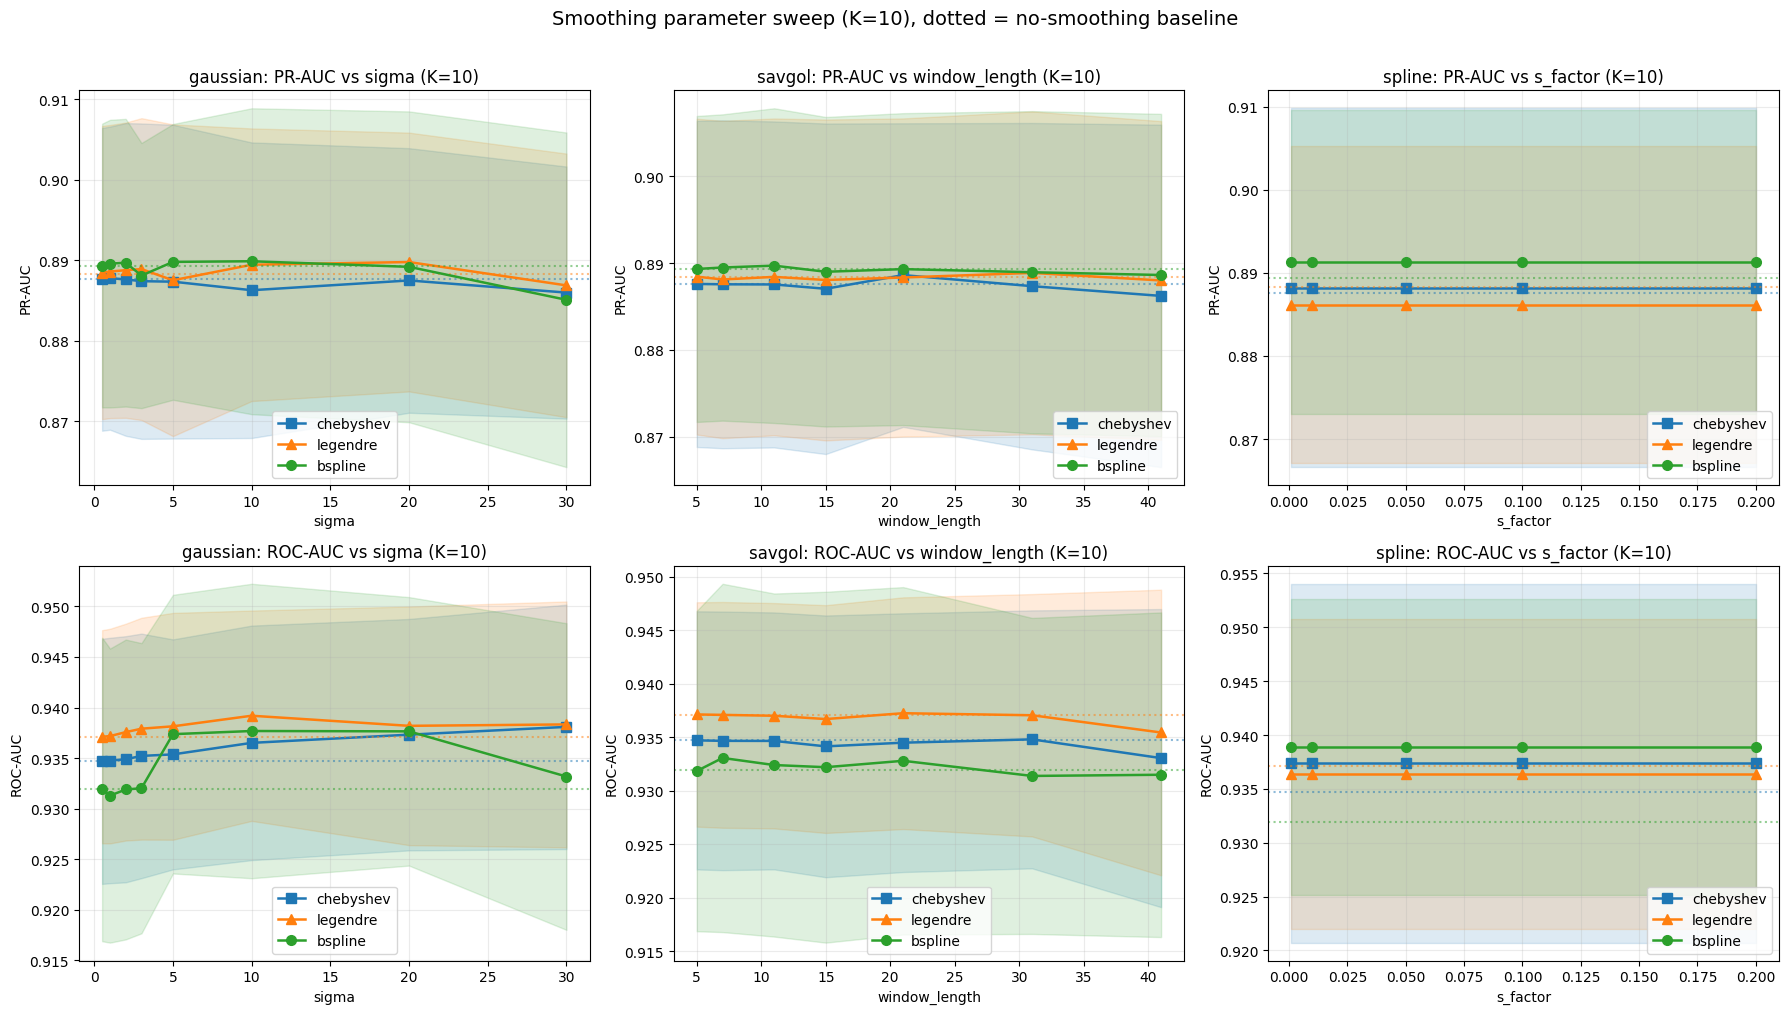

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_sweep("gaussian", "sigma", metric="pr_auc", ax=axes[0, 0])
plot_sweep("savgol", "window_length", metric="pr_auc", ax=axes[0, 1])
plot_sweep("spline", "s_factor", metric="pr_auc", ax=axes[0, 2])

plot_sweep("gaussian", "sigma", metric="roc_auc", ax=axes[1, 0])
plot_sweep("savgol", "window_length", metric="roc_auc", ax=axes[1, 1])
plot_sweep("spline", "s_factor", metric="roc_auc", ax=axes[1, 2])

fig.suptitle(f"Smoothing parameter sweep (K={K}), dotted = no-smoothing baseline", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "smoothing_sweep_pr_roc.png", dpi=160, bbox_inches="tight")
plt.show()

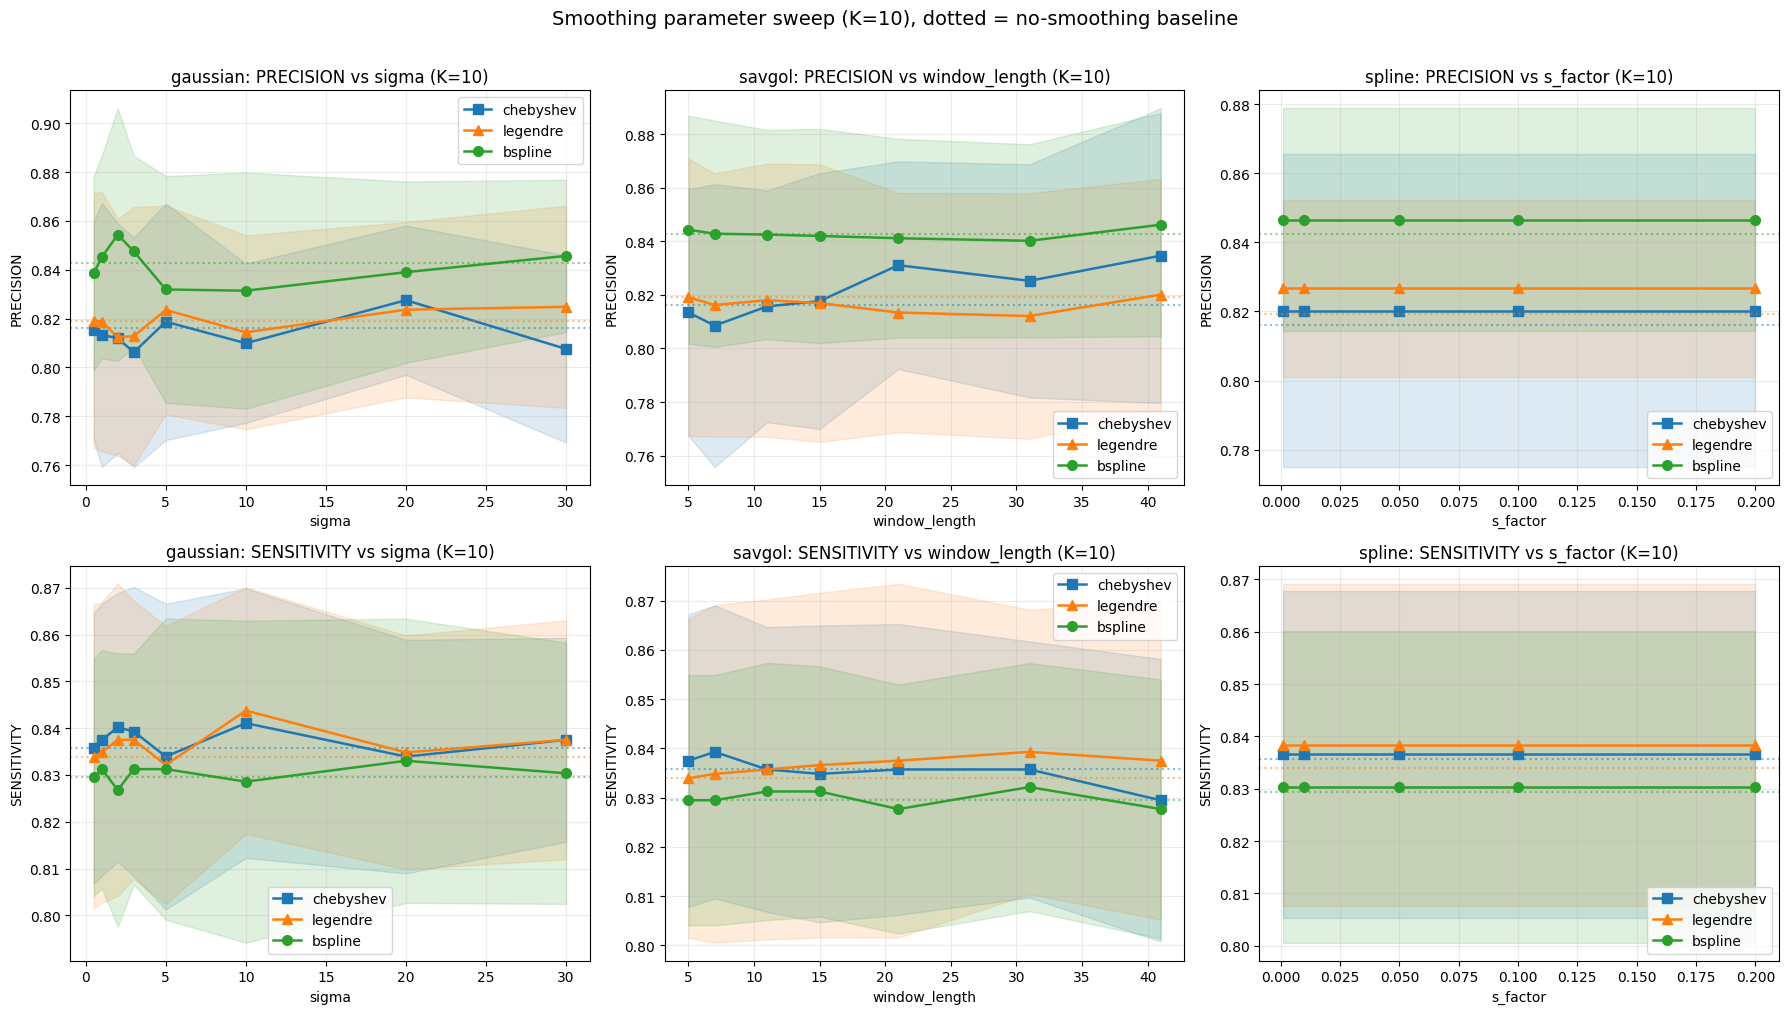

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_sweep("gaussian", "sigma", metric="precision", ax=axes[0, 0])
plot_sweep("savgol", "window_length", metric="precision", ax=axes[0, 1])
plot_sweep("spline", "s_factor", metric="precision", ax=axes[0, 2])

plot_sweep("gaussian", "sigma", metric="sensitivity", ax=axes[1, 0])
plot_sweep("savgol", "window_length", metric="sensitivity", ax=axes[1, 1])
plot_sweep("spline", "s_factor", metric="sensitivity", ax=axes[1, 2])

fig.suptitle(f"Smoothing parameter sweep (K={K}), dotted = no-smoothing baseline", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "smoothing_sweep_prec_sens.png", dpi=160, bbox_inches="tight")
plt.show()

---
## Best configurations

In [20]:
best = (
    summary
    .sort_values("pr_auc_mean", ascending=False)
    .head(15)
    [["basis", "smoothing_method", "param_label",
      "pr_auc_mean", "pr_auc_std",
      "roc_auc_mean", "roc_auc_std",
      "f1_mean", "f1_std",
      "sensitivity_mean", "precision_mean"]]
)
best.style.format({
    "pr_auc_mean": "{:.4f}", "pr_auc_std": "{:.4f}",
    "roc_auc_mean": "{:.4f}", "roc_auc_std": "{:.4f}",
    "f1_mean": "{:.4f}", "f1_std": "{:.4f}",
    "sensitivity_mean": "{:.4f}", "precision_mean": "{:.4f}",
})

,basis,smoothing_method,param_label,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,sensitivity_mean,precision_mean
20,bspline,spline,s_factor=0.2,0.8913,0.0183,0.9389,0.0137,0.8379,0.0214,0.8304,0.8466
19,bspline,spline,s_factor=0.1,0.8913,0.0183,0.9389,0.0137,0.8379,0.0214,0.8304,0.8466
18,bspline,spline,s_factor=0.05,0.8913,0.0183,0.9389,0.0137,0.8379,0.0214,0.8304,0.8466
17,bspline,spline,s_factor=0.01,0.8913,0.0183,0.9389,0.0137,0.8379,0.0214,0.8304,0.8466
16,bspline,spline,s_factor=0.001,0.8913,0.0183,0.9389,0.0137,0.8379,0.0214,0.8304,0.8466
5,bspline,gaussian,sigma=10.0,0.8899,0.0190,0.9377,0.0146,0.8285,0.0203,0.8286,0.8314
4,bspline,gaussian,sigma=5.0,0.8898,0.0171,0.9374,0.0138,0.8301,0.0161,0.8313,0.8319
48,legendre,gaussian,sigma=20.0,0.8898,0.0161,0.9382,0.0118,0.8287,0.0229,0.8348,0.8236
2,bspline,gaussian,sigma=2.0,0.8897,0.0179,0.9319,0.0148,0.8392,0.0265,0.8268,0.8543
11,bspline,savgol,window=11,0.8897,0.0181,0.9324,0.0160,0.8363,0.0253,0.8313,0.8425


---
## Diagnostic: spline smoother produces identical output across s_factor values

All `s_factor` values in the spline sweep yield identical metrics. This is due to
`scipy.interpolate.UnivariateSpline`'s discrete knot-selection (FITPACK): for our
spectra (BP n=154, RP n=193) and the tested `s = n * s_factor` range (0.15 to 31),
the internal knot schedule jumps past all tested thresholds in a single refinement
step, so every `s_factor` resolves to the **same** spline fit.

In [ ]:
from scipy.interpolate import UnivariateSpline

SPLINE_SFACTORS_DIAG = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0]
example_flux = bp.flux[0]
x = np.arange(len(example_flux), dtype=float)
n = len(example_flux)

print(f"BP spectrum length: {n}")
print(f"{'s_factor':>10s}  {'s':>10s}  {'n_knots':>8s}  {'RSS':>14s}  {'max|diff| vs first':>20s}")
print("-" * 72)

first_y = None
for sf in SPLINE_SFACTORS_DIAG:
    s = n * sf
    spl = UnivariateSpline(x, example_flux, s=s)
    fitted = spl(x)
    rss = float(np.sum((example_flux - fitted) ** 2))
    n_knots = len(spl.get_knots())
    if first_y is None:
        first_y = fitted
        diff_str = "---"
    else:
        diff_str = f"{np.max(np.abs(fitted - first_y)):.2e}"
    print(f"{sf:10.3f}  {s:10.2f}  {n_knots:8d}  {rss:14.6f}  {diff_str:>20s}")

print("\nConclusion: knot count and fitted values are identical for s_factor in [0.001, 0.2].")

---
## Summary heatmaps: PR-AUC, Precision, Sensitivity per (basis, smoothing config)

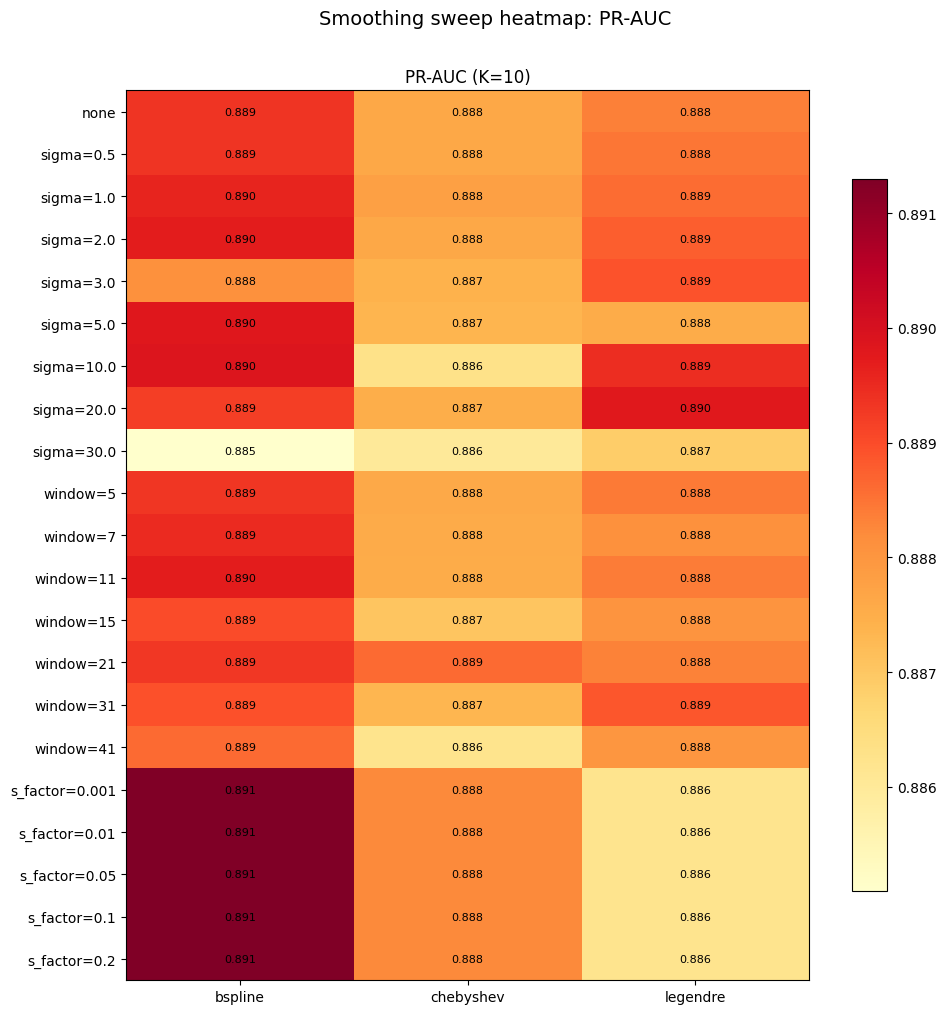

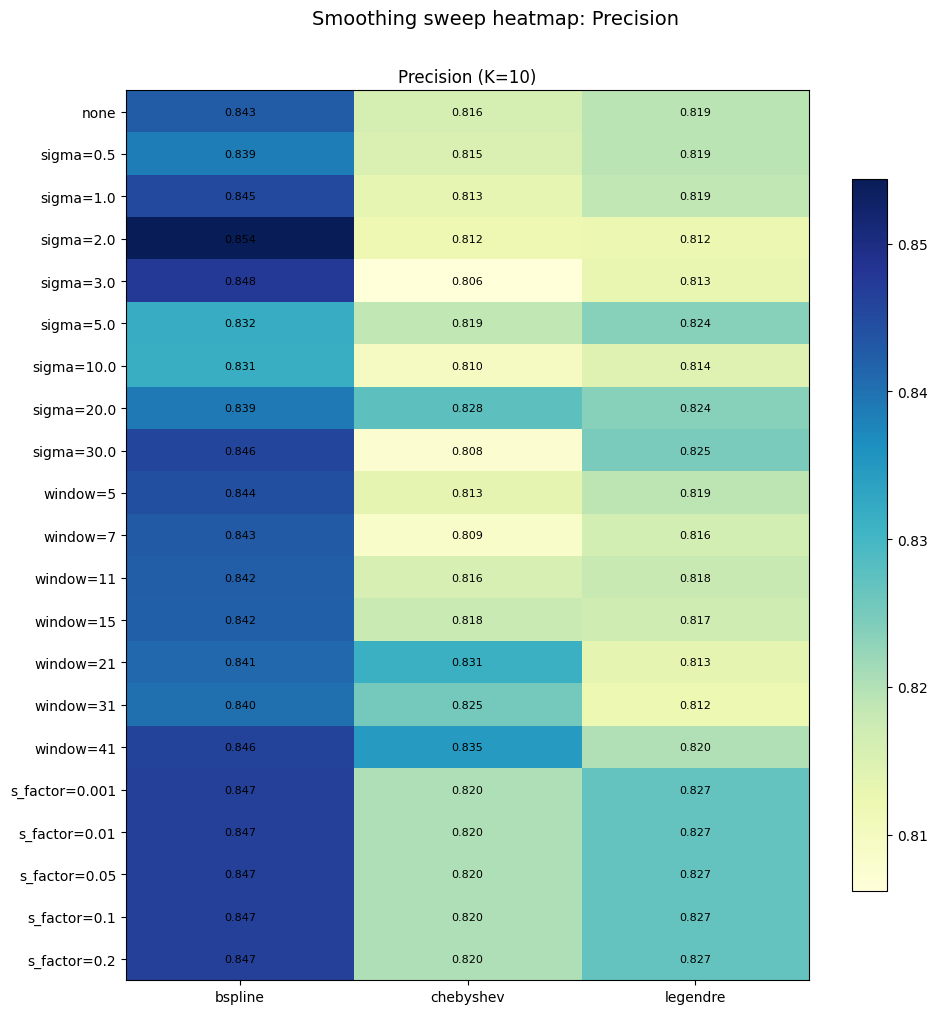

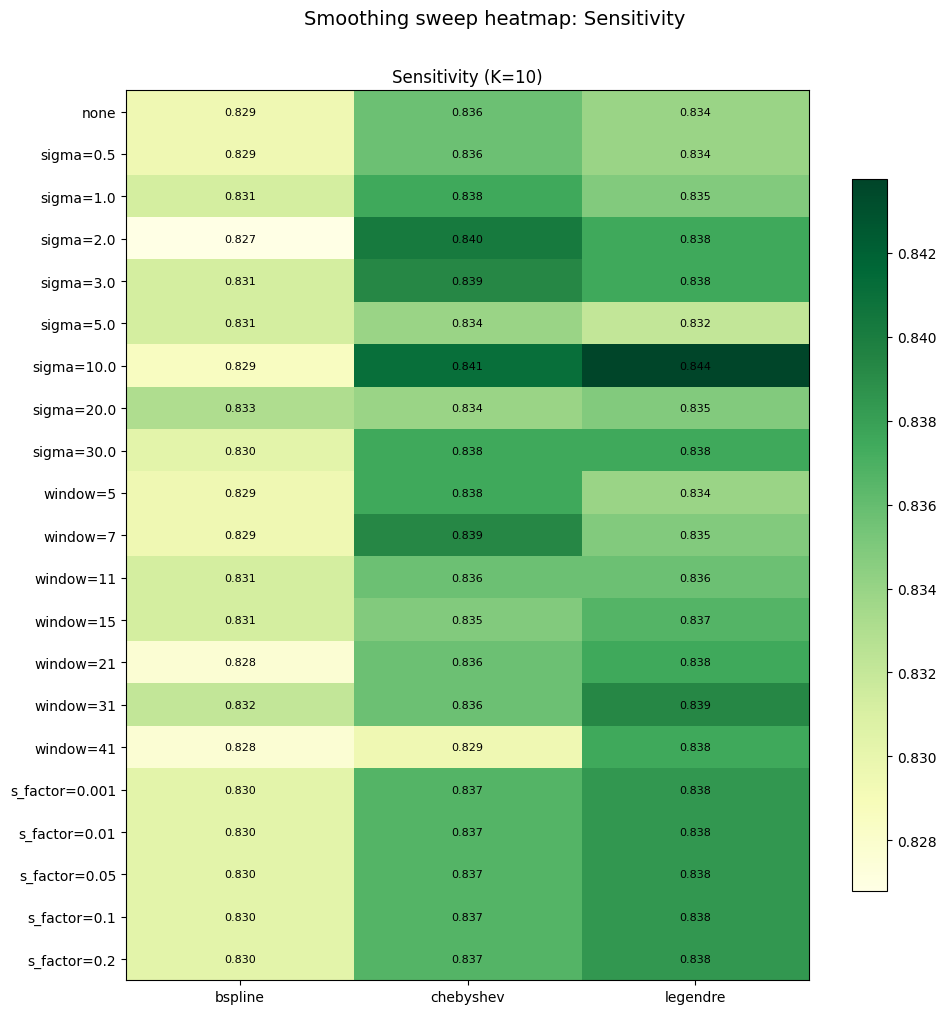

In [21]:
method_order = ["none"]
for s in GAUSSIAN_SIGMAS:
    method_order.append(f"sigma={s}")
for w in SAVGOL_WINDOWS:
    method_order.append(f"window={w}")
for s in SPLINE_SFACTORS:
    method_order.append(f"s_factor={s}")

heatmap_metrics = [
    ("pr_auc_mean", "PR-AUC", "YlOrRd"),
    ("precision_mean", "Precision", "YlGnBu"),
    ("sensitivity_mean", "Sensitivity", "YlGn"),
]

figs = []
axes_list = []
for idx, (col, label, cmap) in enumerate(heatmap_metrics):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
    pivot = summary.pivot_table(
        index="param_label", columns="basis", values=col, aggfunc="first",
    )
    pivot = pivot.reindex([m for m in method_order if m in pivot.index])

    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"{label} (K={K})")
    fig.suptitle(f"Smoothing sweep heatmap: {label}", fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"smoothing_sweep_heatmap_{col}.png", dpi=160, bbox_inches="tight")
    plt.show()
    figs.append(fig)
    axes_list.append(ax)

---
## Per-basis best smoothing config

In [22]:
for basis in BASES:
    bdf = summary[summary["basis"] == basis].sort_values("pr_auc_mean", ascending=False)
    top = bdf.head(5)[["smoothing_method", "param_label", "pr_auc_mean", "pr_auc_std",
                        "roc_auc_mean", "f1_mean", "sensitivity_mean"]]
    print(f"\n{'='*60}")
    print(f"  {basis.upper()} -- top 5 configs by PR-AUC")
    print(f"{'='*60}")
    print(top.to_string(index=False, float_format="{:.4f}".format))


  CHEBYSHEV -- top 5 configs by PR-AUC
smoothing_method   param_label  pr_auc_mean  pr_auc_std  roc_auc_mean  f1_mean  sensitivity_mean
          savgol     window=21       0.8886      0.0175        0.9345   0.8326            0.8357
          spline  s_factor=0.2       0.8882      0.0216        0.9374   0.8273            0.8366
          spline  s_factor=0.1       0.8882      0.0216        0.9374   0.8273            0.8366
          spline s_factor=0.05       0.8882      0.0216        0.9374   0.8273            0.8366
          spline s_factor=0.01       0.8882      0.0216        0.9374   0.8273            0.8366

  LEGENDRE -- top 5 configs by PR-AUC
smoothing_method param_label  pr_auc_mean  pr_auc_std  roc_auc_mean  f1_mean  sensitivity_mean
        gaussian  sigma=20.0       0.8898      0.0161        0.9382   0.8287            0.8348
        gaussian  sigma=10.0       0.8894      0.0169        0.9392   0.8281            0.8438
        gaussian   sigma=3.0       0.8889      0.0187 